# Predicción de ventas netas

### Ventas - devolciones por cada día

In [3]:
#conectamos con DRIVE para cargar el dataset
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import pandas as pd

# Cargar ambos resultados de test
#ventas_test = pd.read_csv('/content/prediccion_test_ventas-excluido-pico-ventas.csv')
#devoluc_test = pd.read_csv('/content/prediccion_test_devoluciones-excluido-pico-ventas.csv')


ventas_test = pd.read_csv('/content/prediccion_test_ventas.csv')
devoluc_test = pd.read_csv('/content/prediccion_test_devoluciones.csv')


print('VENTAS: \n')
display(ventas_test)
print('\n')
print('DEVOLUCIONES: \n')
display(devoluc_test)

VENTAS: 



,date,daily_sales,month,day_of_month,day_of_week,is_weekend,sales_lag_1,sales_lag_7,predicted_sales,actual_sales,prediction_error
0,2011-11-09,62359.13,11,9,2,0,54617.93,28809.90,57591.272711,62359.13,4767.857289
1,2011-11-10,68593.52,11,10,3,0,62359.13,44826.29,66124.693140,68593.52,2468.826860
2,2011-11-11,52808.40,11,11,4,0,68593.52,62590.96,58872.571544,52808.40,-6064.171544
3,2011-11-13,32213.29,11,13,6,1,52808.40,61799.62,44810.087385,32213.29,-12596.797385
4,2011-11-14,111348.61,11,14,0,0,32213.29,42153.85,62299.710316,111348.61,49048.899684
5,2011-11-15,58121.76,11,15,1,0,111348.61,84150.01,67606.071132,58121.76,-9484.311132
6,2011-11-16,62258.29,11,16,2,0,58121.76,54617.93,61292.169742,62258.29,966.120258
7,2011-11-17,58531.66,11,17,3,0,62258.29,62359.13,69135.641417,58531.66,-10603.981417
8,2011-11-18,49595.48,11,18,4,0,58531.66,68593.52,61166.871977,49595.48,-11571.391977
9,2011-11-20,32971.76,11,20,6,1,49595.48,52808.40,45604.911543,32971.76,-12633.151543




DEVOLUCIONES: 



,date,daily_returns,month,day_of_month,day_of_week,is_weekend,returns_lag_1,returns_lag_7,predicted_returns,actual_returns,prediction_error
0,2011-11-09,978.34,11,9,2,0,1019.39,601.66,1069.089812,978.34,-90.749812
1,2011-11-10,520.65,11,10,3,0,978.34,614.75,1117.612632,520.65,-596.962632
2,2011-11-11,319.48,11,11,4,0,520.65,2537.17,784.826618,319.48,-465.346618
3,2011-11-12,0.00,11,12,5,1,319.48,0.00,245.651018,0.00,-245.651018
4,2011-11-13,83.10,11,13,6,1,0.00,33.94,421.815531,83.10,-338.715531
5,2011-11-14,724.93,11,14,0,0,83.10,1697.92,1622.402023,724.93,-897.472023
6,2011-11-15,149.04,11,15,1,0,724.93,1019.39,1245.885622,149.04,-1096.845622
7,2011-11-16,1531.47,11,16,2,0,149.04,978.34,1393.677274,1531.47,137.792726
8,2011-11-17,383.41,11,17,3,0,1531.47,520.65,1404.623394,383.41,-1021.213394
9,2011-11-18,857.38,11,18,4,0,383.41,319.48,1025.262863,857.38,-167.882863


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import os

resultados_caja_neta = []

# Unir y restar
df_mes_objetivo = pd.merge(ventas_test, devoluc_test, on='date')

# Ventas reales
df_mes_objetivo['real_final_sales'] = df_mes_objetivo['actual_sales'] - df_mes_objetivo['actual_returns']
display(df_mes_objetivo[['date', 'actual_sales', 'actual_returns', 'real_final_sales',]])

# Predicciones
df_mes_objetivo['predicted_final_sales'] = df_mes_objetivo['predicted_sales'] - df_mes_objetivo['predicted_returns']
display(df_mes_objetivo[['date', 'predicted_sales', 'predicted_returns', 'predicted_final_sales']])

mae = mean_absolute_error(df_mes_objetivo['real_final_sales'], df_mes_objetivo['predicted_final_sales'])
rmse = np.sqrt(mean_squared_error(df_mes_objetivo['real_final_sales'], df_mes_objetivo['predicted_final_sales']))
r2 = r2_score(df_mes_objetivo['real_final_sales'], df_mes_objetivo['predicted_final_sales'])

# Guardar resultados
resultados_caja_neta.append({
    "Modelo": 'PROPHET',
    "MAE Neto (£)": mae,
    "RMSE Neto (£)": rmse,
    "R2 Neto": r2
})


df_res_netos = pd.DataFrame(resultados_caja_neta).sort_values(by="RMSE Neto (£)", ascending=True)

print("\n" + "="*80)
print(" PRECISIÓN EN EL FLUJO DE CAJA NETO ")
print("="*80)
display(df_res_netos.round(2))

,date,actual_sales,actual_returns,real_final_sales
0,2011-11-09,62359.13,978.34,61380.79
1,2011-11-10,68593.52,520.65,68072.87
2,2011-11-11,52808.40,319.48,52488.92
3,2011-11-13,32213.29,83.10,32130.19
4,2011-11-14,111348.61,724.93,110623.68
5,2011-11-15,58121.76,149.04,57972.72
6,2011-11-16,62258.29,1531.47,60726.82
7,2011-11-17,58531.66,383.41,58148.25
8,2011-11-18,49595.48,857.38,48738.10
9,2011-11-20,32971.76,51.86,32919.90


,date,predicted_sales,predicted_returns,predicted_final_sales
0,2011-11-09,57591.272711,1069.089812,56522.182899
1,2011-11-10,66124.693140,1117.612632,65007.080508
2,2011-11-11,58872.571544,784.826618,58087.744926
3,2011-11-13,44810.087385,421.815531,44388.271853
4,2011-11-14,62299.710316,1622.402023,60677.308293
5,2011-11-15,67606.071132,1245.885622,66360.185510
6,2011-11-16,61292.169742,1393.677274,59898.492468
7,2011-11-17,69135.641417,1404.623394,67731.018023
8,2011-11-18,61166.871977,1025.262863,60141.609115
9,2011-11-20,45604.911543,560.577076,45044.334467



 RANKING DEFINITIVO: PRECISIÓN EN EL FLUJO DE CAJA NETO 


,Modelo,MAE Neto (£),RMSE Neto (£),R2 Neto
0,PROPHET,12942.21,17417.79,0.13


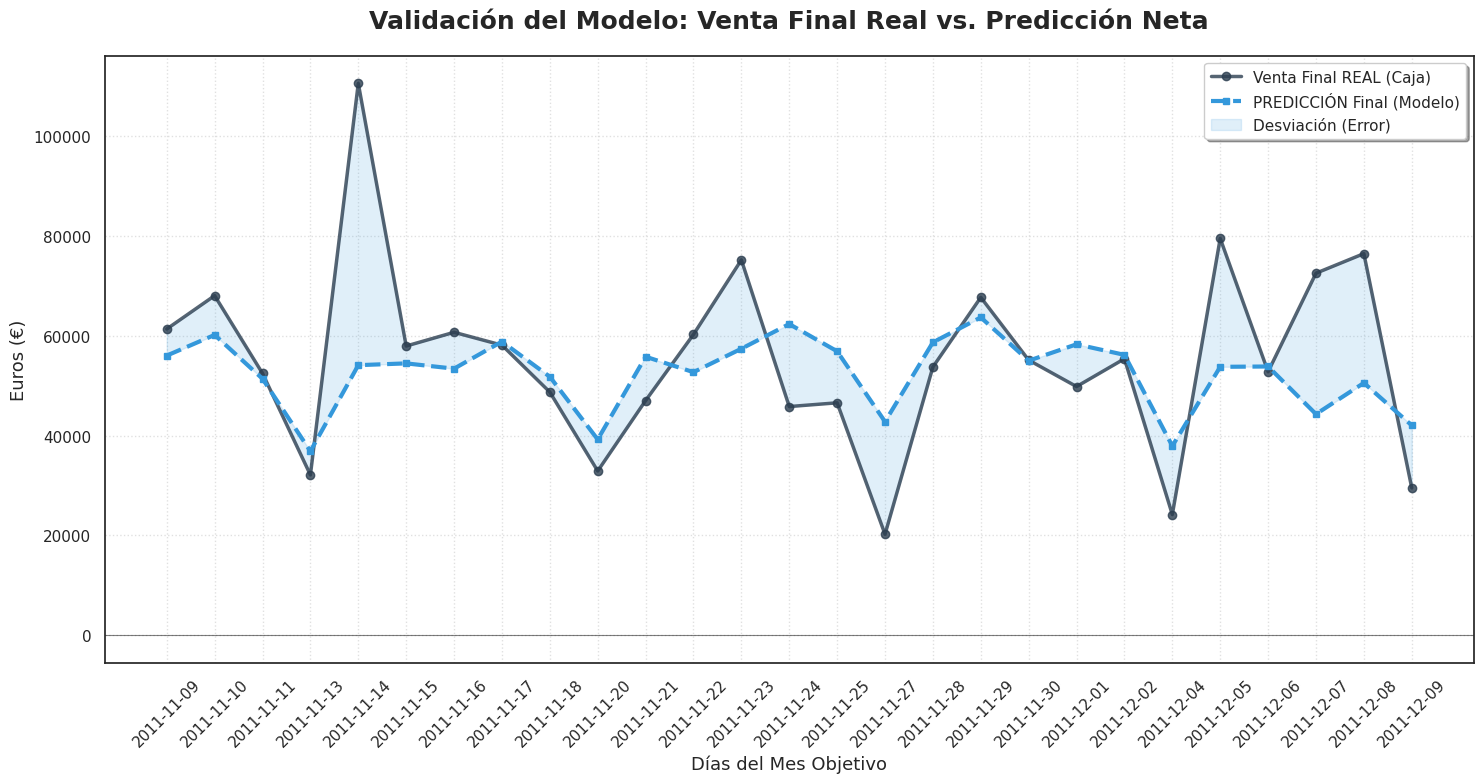

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configuración de estilo profesional
sns.set_theme(style="white")
plt.figure(figsize=(15, 8))

# 2. Dibujar la Venta Final Real (Línea de referencia)
plt.plot(df_mes_objetivo['date'], df_mes_objetivo['real_final_sales'],
         label='Venta Final REAL (Caja)', color='#2C3E50',
         linewidth=2.5, marker='o', markersize=6, alpha=0.8)

# 3. Dibujar la Predicción Final (Línea del modelo)
plt.plot(df_mes_objetivo['date'], df_mes_objetivo['predicted_final_sales'],
         label='PREDICCIÓN Final (Modelo)', color='#3498DB',
         linewidth=3, linestyle='--', marker='s', markersize=4)

# 4. Sombreado entre ambas (Visualiza el error de predicción)
plt.fill_between(df_mes_objetivo['date'],
                 df_mes_objetivo['real_final_sales'],
                 df_mes_objetivo['predicted_final_sales'],
                 color='#3498DB', alpha=0.15, label='Desviación (Error)')

# 5. Anotaciones y Estética
plt.title('Validación del Modelo: Venta Final Real vs. Predicción Neta', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Días del Mes Objetivo', fontsize=13)
plt.ylabel('Euros (€)', fontsize=13)

# Formatear el eje X para que no se amontonen las fechas
plt.xticks(rotation=45)

# Añadir leyenda y cuadrícula
plt.legend(loc='upper right', frameon=True, shadow=True, fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)

# Añadir una línea horizontal en 0 si hubiera valores negativos (opcional)
plt.axhline(0, color='black', linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.show()